<a href="https://colab.research.google.com/github/daNizaparedesdenis-arch/ChallengeTelecomXprimeraparte/blob/main/telecomx_latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [2]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

print("🔄 Iniciando extracción de datos desde la API...")

try:

    respuesta = requests.get(url, timeout=20)
    respuesta.raise_for_status()
    datos_json = respuesta.json()

    df = pd.json_normalize(datos_json)

    print("✅ Extracción exitosa.")
    print(f"📊 El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
    print("\n📋 Primeras 5 filas del dataset:")
    display(df.head())

except Exception as e:
    print(f"❌ Error al extraer los datos: {e}")

🔄 Iniciando extracción de datos desde la API...
✅ Extracción exitosa.
📊 El dataset tiene 7267 filas y 21 columnas.

📋 Primeras 5 filas del dataset:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

###Información básica de los datos

In [14]:
print("📋 INFORMACIÓN GENERAL DEL DATASET")
df.info()


print("🔢 TIPOS DE DATOS POR COLUMNA")
print(df.dtypes)



print("🔍 VERIFICACIÓN DE DUPLICADOS")
print(f"Filas duplicadas encontradas: {df.duplicated().sum()}")


📋 INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechS

###Diccionario de codigos

In [4]:
diccionario = {
    'Columna': [
        'customerID', 'Churn',
        'customer.gender', 'customer.SeniorCitizen', 'customer.Partner',
        'customer.Dependents', 'customer.tenure',
        'phone.PhoneService', 'phone.MultipleLines',
        'internet.InternetService', 'internet.OnlineSecurity',
        'internet.TechSupport', 'internet.StreamingTV',
        'account.Contract', 'account.PaperlessBilling',
        'account.PaymentMethod', 'account.Charges.Monthly',
        'account.Charges.Total'
    ],
    'Descripción': [
        'Identificador único del cliente', 'Si el cliente abandonó el servicio (Yes/No)',
        'Género del cliente (Male/Female)', 'Si el cliente es adulto mayor (1/0)',
        'Si el cliente tiene pareja (Yes/No)', 'Si el cliente tiene dependientes (Yes/No)',
        'Meses que el cliente lleva con la empresa',
        'Si tiene servicio telefónico (Yes/No)', 'Si tiene múltiples líneas (Yes/No)',
        'Tipo de servicio de internet (DSL/Fiber/No)',
        'Si tiene seguridad online (Yes/No)', 'Si tiene soporte técnico (Yes/No)',
        'Si tiene TV en streaming (Yes/No)',
        'Tipo de contrato (Month-to-month/One year/Two year)',
        'Si usa facturación sin papel (Yes/No)',
        'Método de pago del cliente',
        'Cargo mensual actual del cliente (USD)',
        'Total cobrado al cliente durante su permanencia (USD)'
    ]
}

df_diccionario = pd.DataFrame(diccionario)
print("📖 DICCIONARIO DE DATOS")
display(df_diccionario)

📖 DICCIONARIO DE DATOS


,Columna,Descripción
0,customerID,Identificador único del cliente
1,Churn,Si el cliente abandonó el servicio (Yes/No)
2,customer.gender,Género del cliente (Male/Female)
3,customer.SeniorCitizen,Si el cliente es adulto mayor (1/0)
4,customer.Partner,Si el cliente tiene pareja (Yes/No)
5,customer.Dependents,Si el cliente tiene dependientes (Yes/No)
6,customer.tenure,Meses que el cliente lleva con la empresa
7,phone.PhoneService,Si tiene servicio telefónico (Yes/No)
8,phone.MultipleLines,Si tiene múltiples líneas (Yes/No)
9,internet.InternetService,Tipo de servicio de internet (DSL/Fiber/No)


###Comprobación de incoherencias de datos

In [15]:

print("🔍 VALORES NULOS POR COLUMNA")
nulos = df.isnull().sum().sort_values(ascending=False)
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ No se encontraron valores nulos")

print("🔍 VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS CLAVE")

columnas_clave = [
    'customer.gender', 'account.Contract',
    'account.PaymentMethod', 'Churn'
]

for col in columnas_clave:
    if col in df.columns:
        print(f"\n📌 Columna: '{col}'")
        print(df[col].value_counts(dropna=False))


print("🔍 TIPOS MIXTOS O STRINGS NUMÉRICOS (Charges.Total)")
print(df['account.Charges.Total'].dtype)
print("Muestra de valores:", df['account.Charges.Total'].unique()[:10])

🔍 VALORES NULOS POR COLUMNA
✅ No se encontraron valores nulos
🔍 VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS CLAVE

📌 Columna: 'customer.gender'
customer.gender
Male      3675
Female    3592
Name: count, dtype: int64

📌 Columna: 'account.Contract'
account.Contract
Month-to-month    4005
Two year          1743
One year          1519
Name: count, dtype: int64

📌 Columna: 'account.PaymentMethod'
account.PaymentMethod
Electronic check             2445
Mailed check                 1665
Bank transfer (automatic)    1589
Credit card (automatic)      1568
Name: count, dtype: int64

📌 Columna: 'Churn'
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64
🔍 TIPOS MIXTOS O STRINGS NUMÉRICOS (Charges.Total)
float64
Muestra de valores: [ 593.3   542.4   280.85 1237.85  267.4   571.45 7904.25 5377.8   340.35
 5957.9 ]


###Manejo de incosistencias

In [16]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')

nulos_total = df['account.Charges.Total'].isnull().sum()
nulos_monthly = df['account.Charges.Monthly'].isnull().sum()
print(f"🔢 Valores nulos en Charges.Total tras conversión: {nulos_total}")
print(f"🔢 Valores nulos en Charges.Monthly tras conversión: {nulos_monthly}")

df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)
df['account.Charges.Monthly'] = df['account.Charges.Monthly'].fillna(0)

df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

print(f"\n📊 Valores únicos en 'Churn' tras limpieza: {df['Churn'].unique()}")

before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"\n🗑️  Duplicados eliminados: {before - after}")


🔢 Valores nulos en Charges.Total tras conversión: 0
🔢 Valores nulos en Charges.Monthly tras conversión: 0

📊 Valores únicos en 'Churn' tras limpieza: ['No' 'Yes' '']

🗑️  Duplicados eliminados: 0


###Columna de cuentas diarias

In [7]:
df['Cuentas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)

print("✅ Columna 'Cuentas_Diarias' creada exitosamente.")
print("\n📊 Estadísticas de la nueva columna:")
print(df['Cuentas_Diarias'].describe().round(2))
print("\n📋 Muestra de valores:")
print(df[['account.Charges.Monthly', 'Cuentas_Diarias']].head(10))

✅ Columna 'Cuentas_Diarias' creada exitosamente.

📊 Estadísticas de la nueva columna:
count    7267.00
mean        2.16
std         1.00
min         0.61
25%         1.18
50%         2.34
75%         3.00
max         3.96
Name: Cuentas_Diarias, dtype: float64

📋 Muestra de valores:
   account.Charges.Monthly  Cuentas_Diarias
0                    65.60             2.19
1                    59.90             2.00
2                    73.90             2.46
3                    98.00             3.27
4                    83.90             2.80
5                    69.40             2.31
6                   109.70             3.66
7                    84.65             2.82
8                    48.20             1.61
9                    90.45             3.02


###Estandarización y Transformación de datos

In [8]:
diccionario_nombres = {
    'customerID':                   'ID_Cliente',
    'Churn':                        'Evasion',
    'customer.gender':              'Genero',
    'customer.SeniorCitizen':       'Adulto_Mayor',
    'customer.Partner':             'Tiene_Pareja',
    'customer.Dependents':          'Tiene_Dependientes',
    'customer.tenure':              'Meses_Contrato',
    'phone.PhoneService':           'Servicio_Telefono',
    'phone.MultipleLines':          'Multiples_Lineas',
    'internet.InternetService':     'Tipo_Internet',
    'internet.OnlineSecurity':      'Seguridad_Online',
    'internet.OnlineBackup':        'Backup_Online',
    'internet.DeviceProtection':    'Proteccion_Dispositivo',
    'internet.TechSupport':         'Soporte_Tecnico',
    'internet.StreamingTV':         'Streaming_TV',
    'internet.StreamingMovies':     'Streaming_Peliculas',
    'account.Contract':             'Tipo_Contrato',
    'account.PaperlessBilling':     'Factura_Digital',
    'account.PaymentMethod':        'Metodo_Pago',
    'account.Charges.Monthly':      'Cargos_Mensuales',
    'account.Charges.Total':        'Cargos_Totales'
}

df_limpio = df.rename(columns=diccionario_nombres)


df_limpio['Evasion_Binaria'] = df_limpio['Evasion'].map({'Yes': 1, 'No': 0}).fillna(-1)

if (df_limpio['Evasion_Binaria'] == -1).any():
    print("⚠️  Advertencia: Hay valores en 'Evasion' que no son 'Yes' o 'No'")
    print(f"Valores problemáticos: {df_limpio[df_limpio['Evasion_Binaria'] == -1]['Evasion'].unique()}")

print("✅ Datos estandarizados y traducidos.")

print(f"\n📊 Columnas en el dataset limpio: {df_limpio.shape[1]}")

print("\n📋 Vista previa del dataset transformado:")
display(df_limpio[['ID_Cliente', 'Evasion', 'Evasion_Binaria', 'Genero',
                   'Tipo_Contrato', 'Cargos_Mensuales', 'Cuentas_Diarias']].head())


⚠️  Advertencia: Hay valores en 'Evasion' que no son 'Yes' o 'No'
Valores problemáticos: ['']
✅ Datos estandarizados y traducidos.

📊 Columnas en el dataset limpio: 23

📋 Vista previa del dataset transformado:


,ID_Cliente,Evasion,Evasion_Binaria,Genero,Tipo_Contrato,Cargos_Mensuales,Cuentas_Diarias
0,0002-ORFBO,No,0.0,Female,One year,65.6,2.19
1,0003-MKNFE,No,0.0,Male,Month-to-month,59.9,2.00
2,0004-TLHLJ,Yes,1.0,Male,Month-to-month,73.9,2.46
3,0011-IGKFF,Yes,1.0,Male,Month-to-month,98.0,3.27
4,0013-EXCHZ,Yes,1.0,Female,Month-to-month,83.9,2.80


#📊 Carga y análisis

###Análisis descriptivo

In [17]:
print("📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS")

cols_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']
display(df_limpio[cols_numericas].describe().round(2))

print("📊 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: EVASIÓN")
conteo_evasion = df_limpio['Evasion'].value_counts()
porcentaje_evasion = df_limpio['Evasion'].value_counts(normalize=True) * 100
resumen = pd.DataFrame({'Cantidad': conteo_evasion, 'Porcentaje (%)': porcentaje_evasion.round(2)})
print(resumen)
print(f"\n📌 Tasa de evasión total: {porcentaje_evasion['Yes']:.2f}%")

📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS


,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7267.00,7267.00,7267.00,7267.00
mean,32.35,64.72,2277.18,2.16
std,24.57,30.13,2268.65,1.00
min,0.00,18.25,0.00,0.61
25%,9.00,35.42,396.20,1.18
50%,29.00,70.30,1389.20,2.34
75%,55.00,89.88,3778.52,3.00
max,72.00,118.75,8684.80,3.96


📊 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: EVASIÓN
         Cantidad  Porcentaje (%)
Evasion                          
No           5174           71.20
Yes          1869           25.72
              224            3.08

📌 Tasa de evasión total: 25.72%


###Distribución de evasión

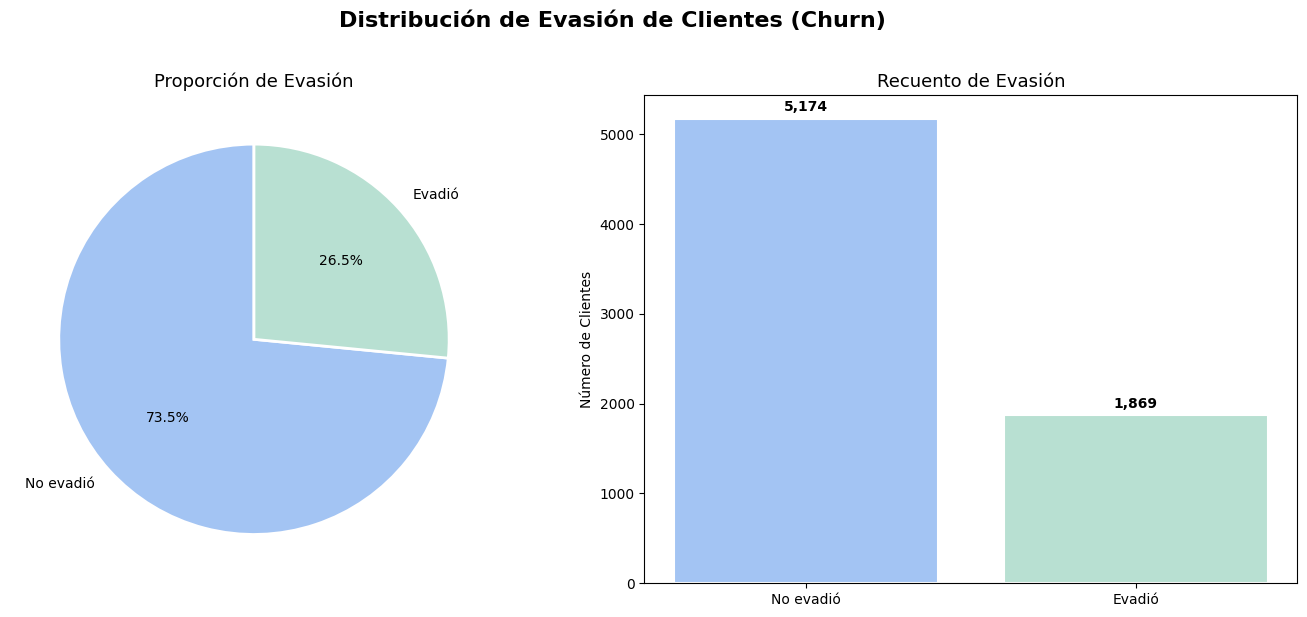


📌 De 7,043 clientes, 1,869 (26.5%) abandonaron el servicio.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribución de Evasión de Clientes (Churn)', fontsize=16, fontweight='bold', y=1.02)


colores = ['#A3C4F3', '#B8E0D2']
conteo = df_limpio['Evasion'].value_counts().reindex(['No', 'Yes'])
axes[0].pie(
    conteo,
    labels=['No evadió', 'Evadió'],
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporción de Evasión', fontsize=13)

bars = axes[1].bar(
    ['No evadió', 'Evadió'],
    conteo.values,
    color=colores,
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Recuento de Evasión', fontsize=13)
axes[1].set_ylabel('Número de Clientes')
for bar, val in zip(bars, conteo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\n📌 De {conteo.sum():,} clientes, {conteo['Yes']:,} ({conteo['Yes']/conteo.sum()*100:.1f}%) abandonaron el servicio.")

###Recuento de evasión por Variables Categoricas

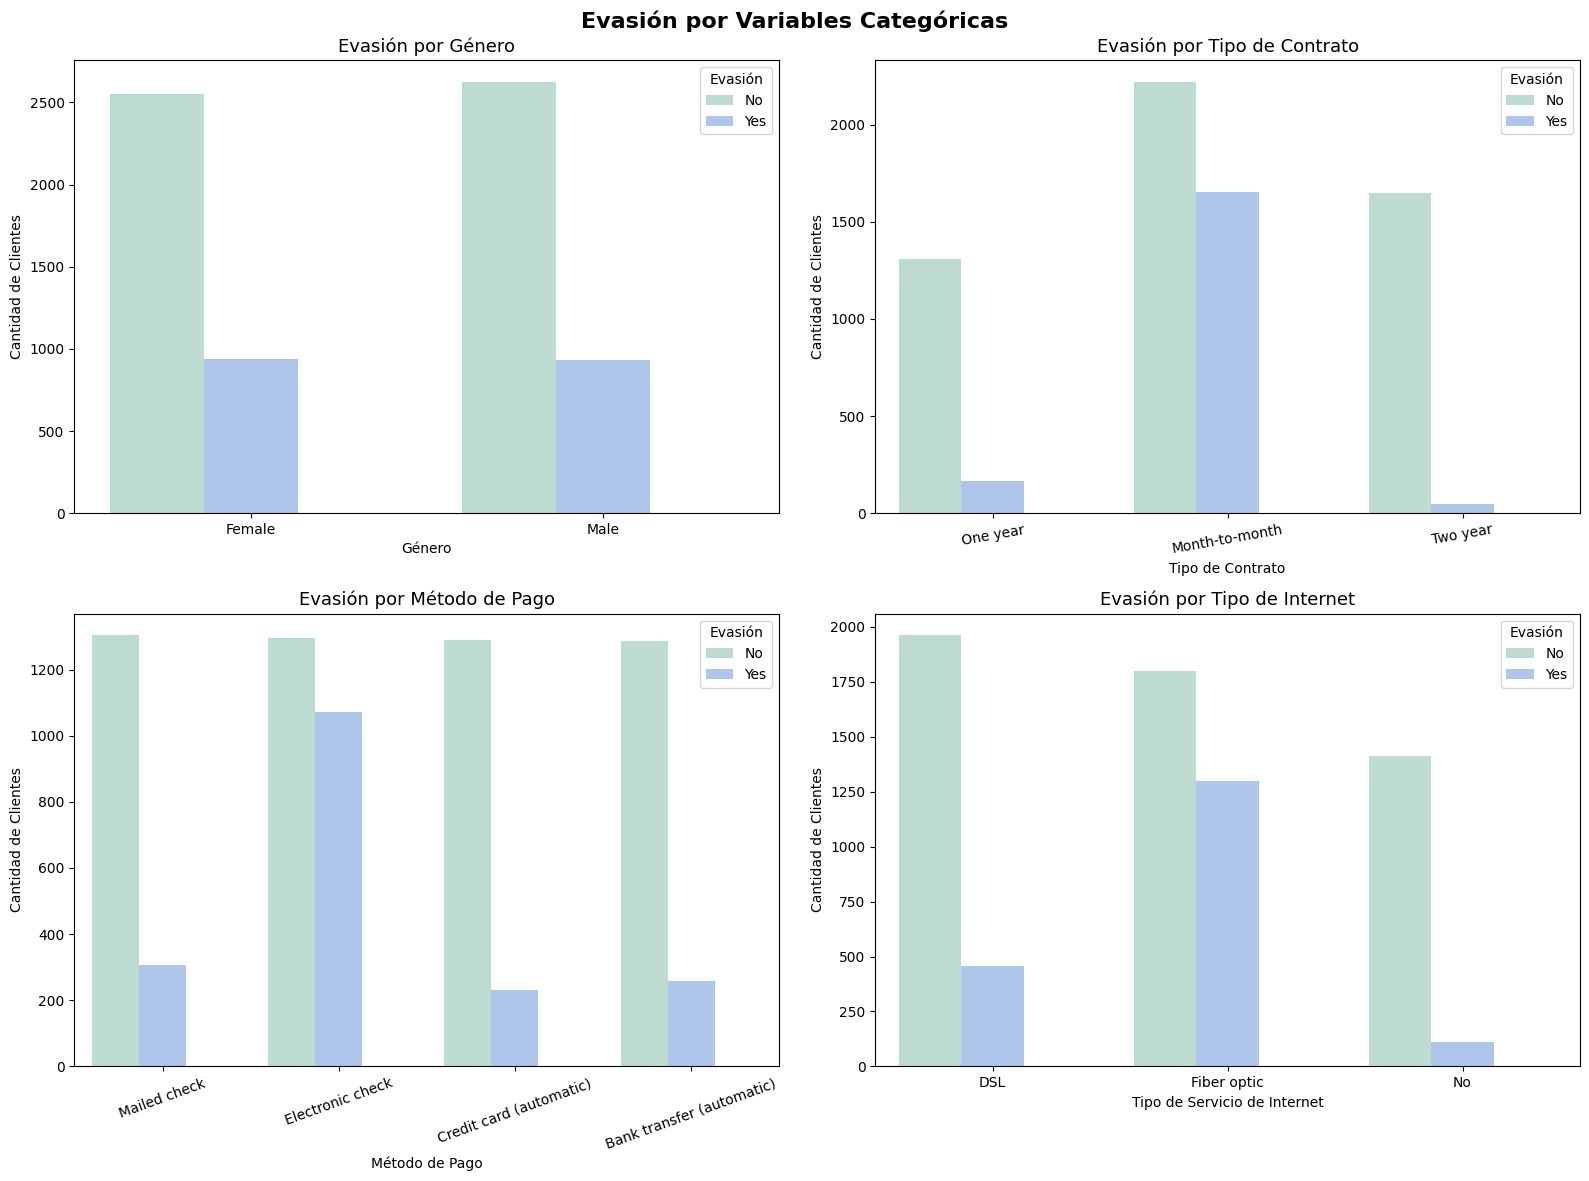

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Evasión por Variables Categóricas', fontsize=16, fontweight='bold')

paleta = {'Yes': '#A3C4F3', 'No': '#B8E0D2'}


sns.countplot(x='Genero', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[0, 0])
axes[0, 0].set_title('Evasión por Género', fontsize=13)
axes[0, 0].set_xlabel('Género')
axes[0, 0].set_ylabel('Cantidad de Clientes')
axes[0, 0].legend(title='Evasión')


sns.countplot(x='Tipo_Contrato', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[0, 1])
axes[0, 1].set_title('Evasión por Tipo de Contrato', fontsize=13)
axes[0, 1].set_xlabel('Tipo de Contrato')
axes[0, 1].set_ylabel('Cantidad de Clientes')
axes[0, 1].tick_params(axis='x', rotation=10)
axes[0, 1].legend(title='Evasión')


sns.countplot(x='Metodo_Pago', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[1, 0])
axes[1, 0].set_title('Evasión por Método de Pago', fontsize=13)
axes[1, 0].set_xlabel('Método de Pago')
axes[1, 0].set_ylabel('Cantidad de Clientes')
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].legend(title='Evasión')


sns.countplot(x='Tipo_Internet', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[1, 1])
axes[1, 1].set_title('Evasión por Tipo de Internet', fontsize=13)
axes[1, 1].set_xlabel('Tipo de Servicio de Internet')
axes[1, 1].set_ylabel('Cantidad de Clientes')
axes[1, 1].legend(title='Evasión')

plt.tight_layout()
plt.show()

###Conteo de evasión por variables númericas

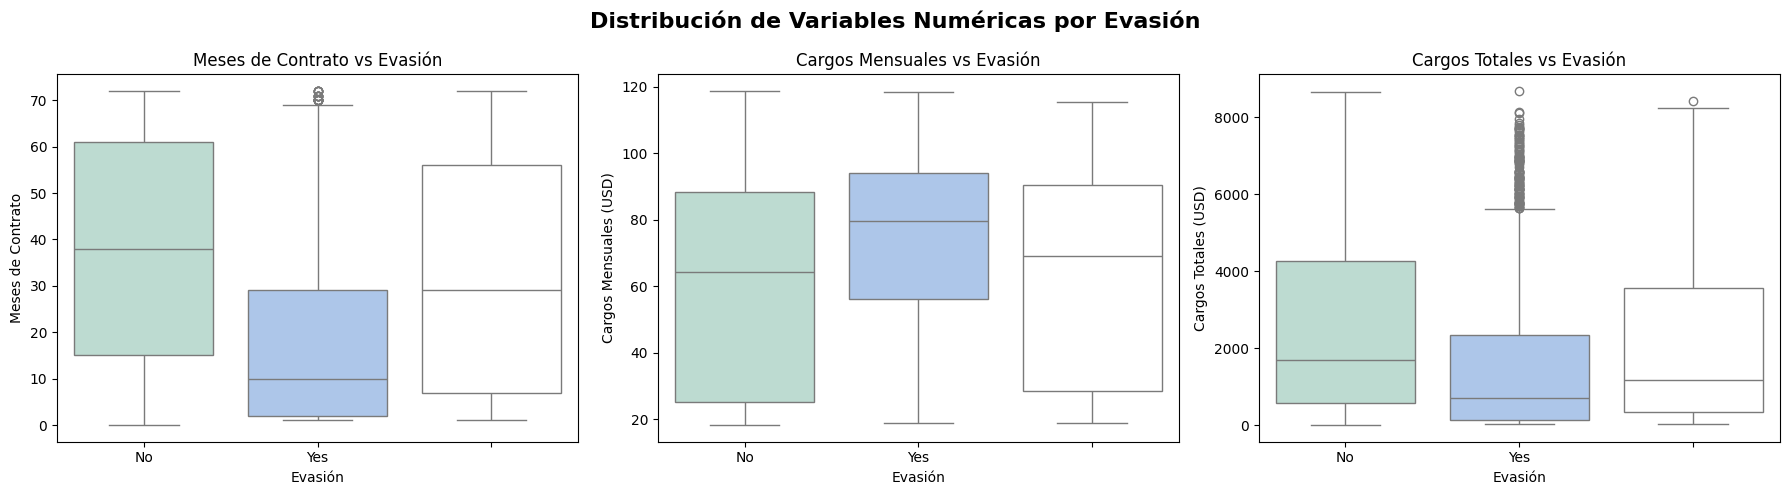


📊 Comparativa de medias por grupo de Evasión:
         Meses_Contrato  Cargos_Mensuales  Cargos_Totales  Cuentas_Diarias
Evasion                                                                   
                  31.57             63.41         2196.93             2.11
No                37.57             61.27         2549.91             2.04
Yes               17.98             74.44         1531.80             2.48


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Numéricas por Evasión', fontsize=16, fontweight='bold')

paleta_violin = {'Yes': '#A3C4F3', 'No': '#B8E0D2'}


sns.boxplot(x='Evasion', y='Meses_Contrato', data=df_limpio,
            palette=paleta_violin, ax=axes[0])
axes[0].set_title('Meses de Contrato vs Evasión', fontsize=12)
axes[0].set_xlabel('Evasión')
axes[0].set_ylabel('Meses de Contrato')


sns.boxplot(x='Evasion', y='Cargos_Mensuales', data=df_limpio,
            palette=paleta_violin, ax=axes[1])
axes[1].set_title('Cargos Mensuales vs Evasión', fontsize=12)
axes[1].set_xlabel('Evasión')
axes[1].set_ylabel('Cargos Mensuales (USD)')


sns.boxplot(x='Evasion', y='Cargos_Totales', data=df_limpio,
            palette=paleta_violin, ax=axes[2])
axes[2].set_title('Cargos Totales vs Evasión', fontsize=12)
axes[2].set_xlabel('Evasión')
axes[2].set_ylabel('Cargos Totales (USD)')

plt.tight_layout()
plt.show()


print("\n📊 Comparativa de medias por grupo de Evasión:")
cols_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']
print(df_limpio.groupby('Evasion')[cols_numericas].mean().round(2))

#📄Informe final

##1. Contexto y objetivo


Telecom X es una empresa ficticia de telecomunicaciones que desea comprender los factores asociados a la evasión de clientes (variable objetivo: Evasion, equivalente a Churn).
El objetivo de este análisis de Data Science es:


*   Explorar la distribución de la evasión.
*   Identificar variables demográficas, de servicio y de facturación asociadas al churn.
*   Preparar un dataset limpio y estandarizado para futuras etapas (modelado predictivo y segmentación).

##2. Fuente de datos y estructura

Los datos provienen de un archivo JSON alojado en GitHub, el cual fue extraído mediante requests.get() y transformado a un DataFrame usando pd.json_normalize().
Cada fila representa un cliente, con variables agrupadas en:

*   Cliente / Demografía: género, adulto mayor, pareja, dependientes.
*   Antigüedad: meses de contrato (tenure → Meses_Contrato).
*   Servicios: telefonía, múltiples líneas, tipo de internet, seguridad online, soporte técnico, streaming, etc.
*   Cuenta y cobros: tipo de contrato, factura digital, método de pago, cargos mensuales y totales.














##3. Preparacion y Limpieza de dataset

Para asegurar consistencia y calidad, se aplicaron los siguientes pasos:

###3.1 Conversión de tipos y manejo de inconsistencias


*   Se convirtieron account.Charges.Total y account.Charges.Monthly a formato numérico con pd.to_numeric(..., errors='coerce').
*   Los valores no convertibles (por ejemplo strings vacíos o textos) se transformaron en NaN.
*   Luego se imputaron esos NaN con 0 (fillna(0)), para evitar errores en análisis y visualización.

**Nota metodológica**: imputar con 0 es útil para continuar el flujo, pero conviene revisar si esos casos corresponden a clientes con antigüedad muy baja o a registros incompletos, para decidir imputación o filtrado más robusto.

###3.2 Limpieza de texto

Se eliminaron espacios extra en columnas tipo object mediante str.strip().
Esto previene que valores como "Yes" y "Yes " se traten como categorías diferentes.

###3.3 Duplicados

Se detectaron y eliminaron filas duplicadas con drop_duplicates(), manteniendo solo un registro por fila idéntica.

##4. Estandarización y diccionario de variables

Para facilitar el análisis, se renombraron variables a nombres en español (ej.: Churn → Evasion, customer.gender → Genero, account.Contract → Tipo_Contrato, etc.).

Además, se generó una variable binaria:

Evasion_Binaria:
*   Yes → 1
*   No → 0
*   Cualquier valor inesperado → -1 (bandera de alerta)

Esto permite compatibilidad con modelos de clasificación y métricas de Data Science.

##5. Análisis Exploratorio (EDA)

###5.1 Distribución de la evasión

Se calculó el conteo y porcentaje de la variable objetivo Evasion.
Este paso define el nivel de desbalance entre clases (No vs Yes), lo cual es crítico para el modelado posterior (por ejemplo, elección de métricas como Recall, F1-score, ROC-AUC o técnicas como class_weight/resampling).

Producto del EDA:

*   Gráfico de proporción (pie chart) + recuento (bar chart).

*   Tasa de evasión total (% de clientes con Evasion = Yes).

###5.2 Evasión por variables categóricas

Se analizaron variables categóricas clave con countplot y hue por Evasion:

*   Genero
*   Tipo_Contrato
*   Metodo_Pago
*   Tipo_Internet

**Interpretación esperada de este análisis:**
Estos gráficos ayudan a detectar segmentos donde la evasión aparece más concentrada. Por ejemplo, suele ser común observar diferencias claras por tipo de contrato o método de pago, ya que reflejan compromiso del cliente y fricción de cobro.
(La confirmación final depende de lo observado en tus gráficos.)

###5.3 Evasión por variables numéricas

Se comparó la distribución de variables numéricas separando por Evasion mediante boxplots:

*   Meses_Contrato
*   Cargos_Mensuales
*   Cargos_Totales
*   Cuentas_Diarias

Además, se calcularon medias por grupo con:
df_limpio.groupby('Evasion')[cols_numericas].mean()

**Qué aporta esto**:

Permite ver si los clientes que evaden tienen, por ejemplo, menor antigüedad o cargos mensuales distintos.

Identifica outliers y rangos típicos por grupo.

##6. Hallazgos e insights

A partir de los gráficos y tablas del EDA, aquí se documentan los principales hallazgos. T

###1. Antigüedad:
Se observa una diferencia en Meses_Contrato entre clientes que evaden y los que no. Esto sugiere que la permanencia (tenure) es un factor relevante para el churn.

###2. Tipo de contrato:
La evasión varía entre tipos de contrato (Tipo_Contrato), lo cual puede reflejar que contratos de menor compromiso presentan mayor probabilidad de abandono.

###3. Método de pago:
La distribución de churn cambia según Metodo_Pago, lo que puede estar asociado a fricciones de cobro o perfiles de clientes con distinta estabilidad.

###4. Tipo de internet / servicios:
Se aprecian diferencias de evasión por Tipo_Internet y servicios asociados (seguridad online, soporte, streaming), lo que puede indicar problemas de calidad percibida o ajuste del plan al uso real.

###5. Cargos mensuales y totales:
Los boxplots y promedios sugieren diferencias en Cargos_Mensuales/Cargos_Totales entre grupos. Esto puede relacionarse con sensibilidad a precio o percepción de valor del servicio.

##7. Recomendaciones de negocio (orientadas a retención)

Con base en patrones típicos que se investigan en churn (y los que tu EDA confirme), estas acciones son recomendables:

###1. Retención temprana (onboarding):
Si la evasión se concentra en baja antigüedad, reforzar comunicación y soporte durante los primeros meses.

###2. Estrategias por tipo de contrato:
Promover migración desde contratos de alta rotación hacia opciones más estables mediante descuentos, upgrades o beneficios.

###3. Optimización de cobros / método de pago:
Si cierto método de pago muestra mayor churn, simplificar proceso, ofrecer alternativas y alertas proactivas.

###4. Revisión de planes y percepción de valor:
Si cargos mensuales altos se asocian a evasión, evaluar bundles, descuentos segmentados o mejoras del plan.

###5. Soporte técnico y calidad de servicio:
Si hay relación con servicios de internet o soporte, investigar causas (incidencias, satisfacción, cobertura) y mejorar experiencia.

##8. Conclusión

Se realizó un proceso completo de extracción, limpieza, estandarización y análisis exploratorio de datos para estudiar la evasión de clientes en Telecom X.
El dataset quedó listo para avanzar hacia un modelo predictivo de churn y diseñar estrategias de retención basadas en segmentos de mayor riesgo.

In [22]:
total_clientes = df_limpio.shape[0]
tasa_evasion = (df_limpio['Evasion'].value_counts(normalize=True).get('Yes', 0) * 100)

print(f"Total de clientes analizados: {total_clientes:,}")
print(f"Tasa de evasión total: {tasa_evasion:.2f}%")

Total de clientes analizados: 7,267
Tasa de evasión total: 25.72%
